In [1]:
from mphelper import ProcessWrapPool
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import itertools
from collections import defaultdict
from pathlib import Path
import pybedtools
import pyBigWig
import seaborn as sns
import numpy as np
from scipy.stats import beta
from scipy.special import betaln
from scipy.optimize import minimize

In [2]:
matplotlib.font_manager.fontManager.addfont(f"{Path.cwd().parent}/font/Arial.ttf")
matplotlib.rcParams["font.family"] = "Arial"
bfontsize = 12
sfontsize = 9
lw = 0.8

In [3]:
PROJECT_DIR_d = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/PROcap/"
PROJECT_DIR_o = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/"

# Beta-binomial model

In [4]:
ds = ["distal", "proximal"]
ps = ["divergent", "unidirectional"]

In [5]:
# Get total counts and DI at divergent elements in different seq depths

def get_features(bed, bws, outputfile):
	b = pybedtools.BedTool(bed)
	bw1, bw2 = [pyBigWig.open(bw) for bw in bws]

	results = []
	index = []
	for i in b:
		chrom, start, end = i.fields[:3]
		index.append("_".join([chrom, start, end]))
		start = int(start)
		end = int(end)
		reads1 = 0
		reads2 = 0
		# pyBigWig: 0-based start, 0-based end; the end is not included
		if bw1.intervals(chrom, start, end+1) != None:
			for start2, end2, score in bw1.intervals(chrom, start, end+1):
				l = min(end+1, end2) - max(start, start2)
				reads1 += abs(score) * l
		if bw2.intervals(chrom, start, end+1) != None:
			for start2, end2, score in bw2.intervals(chrom, start, end+1):
				l = min(end+1, end2) - max(start, start2)
				reads2 += abs(score) * l

		results.append([reads1, reads2, reads1+reads2, (reads1-reads2)/(reads1+reads2)])
		
	df = pd.DataFrame(results, columns=["counts_fwd", "counts_rev", "total_counts", "DI"], index=index)
	df.to_csv(outputfile, sep="\t")

In [6]:
pwpool = ProcessWrapPool(10)

for p, d in itertools.product(ps, ds):
	bed = f"{PROJECT_DIR_d}bed_plot/C1_{p}_{d}.bed"
	bws = [f"{PROJECT_DIR_d}Alignments/brm_C1a_and_C1b_erm_5{k}.bw" for k in ["pl","mn"]]
	outputfile = f"{PROJECT_DIR_d}Analysis/C1_filtered_{p}_{d}_counts_DI.text"
	pwpool.run(get_features, args=[bed, bws, outputfile])

In [7]:
len(pwpool.finished_tasks)

In [8]:
pwpool.close()

## Empirical Bayes

In [9]:
def neg_log_likelihood(alpha):
	alpha = alpha[0]
	if alpha <= 0:
		return np.inf

	ll = np.sum(
		betaln(counts_fwd[d] + alpha, total_counts[d] - counts_fwd[d] + alpha)
		- betaln(alpha, alpha)
	)
	return -ll

In [10]:
# Beta prior: set alpha=beta

alphas = {}
counts_fwd = defaultdict(list)
total_counts = defaultdict(list)
	
for d in ds:
	for p in ps:
		df = pd.read_table(f"{PROJECT_DIR_d}Analysis/C1_filtered_{p}_{d}_counts_DI.text")
		counts_fwd[d].extend(df["counts_fwd"])
		total_counts[d].extend(df["total_counts"])
	counts_fwd[d] = np.array(counts_fwd[d])
	total_counts[d] = np.array(total_counts[d])
	res = minimize(
		neg_log_likelihood,
		x0=[1.0],
		bounds=[(1e-6, None)],
		method="L-BFGS-B"
	)
	
	alphas[d] = res.x[0]

In [11]:
# Source data for SuppFig. 7a and SuppFig. 8a

np.random.seed(42)
df_fwd_frac = {}
for d in alphas:
	n = total_counts[d].astype(int)
	obs_frac = counts_fwd[d] / n

	# Draw one p_i for each locus from the beta prior
	p_sim = np.random.beta(alphas[d], alphas[d], size=len(n))
	# Draw counts on the forward strand given p_i and n_i
	k_sim = np.random.binomial(n, p_sim)
	sim_frac = k_sim / n

	# posterior mean
	post_mean = (counts_fwd[d] + alphas[d]) / (total_counts[d] + 2 * alphas[d])

	results = np.column_stack([n, obs_frac, sim_frac, post_mean])
	df_fwd_frac[d] = pd.DataFrame(results, columns=["Total counts", "Observed forward fraction", "Simulated forward fraction", "Posterior mean"])
	figN = "SuppFig7" if d == "distal" else "SuppFig8"
	df_fwd_frac[d].to_csv(f"{PROJECT_DIR_o}source_data/{figN}ab/{d}_forward_fractions.txt", sep="\t", index=False)

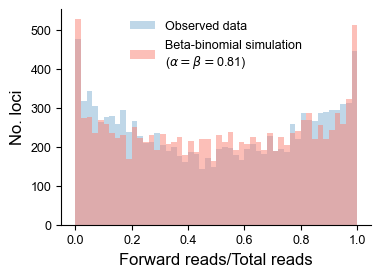

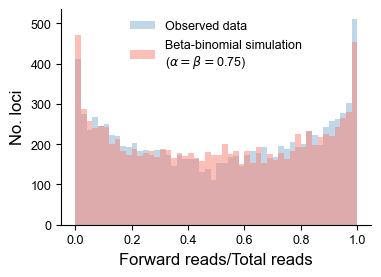

In [12]:
# Check how well the model fits the data

for d in alphas:
	fig, ax = plt.subplots(figsize=(4,2.8))
	
	ax.hist(list(df_fwd_frac[d]["Observed forward fraction"]), bins=50, alpha=0.5, color="#80b1d3", label="Observed data")
	ax.hist(list(df_fwd_frac[d]["Simulated forward fraction"]), bins=50, alpha=0.5, color="#fb8072", label=f"Beta-binomial simulation\n($\\alpha=\\beta=${round(alphas[d],2)})")
	
	ax.set_xlabel("Forward reads/Total reads", fontsize=bfontsize)
	ax.set_ylabel("No. loci", fontsize=bfontsize)
	ax.legend(frameon=False, fontsize=sfontsize)
	ax.spines[["top","right"]].set_visible(False)
	ax.tick_params(labelsize=sfontsize)

	figN = "SuppFig7" if d == "distal" else "SuppFig8"
	plt.savefig(f"{PROJECT_DIR_o}figures/{figN}a.pdf", bbox_inches="tight", transparent=True)

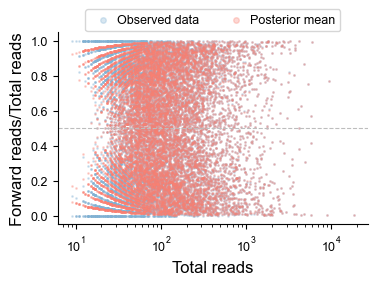

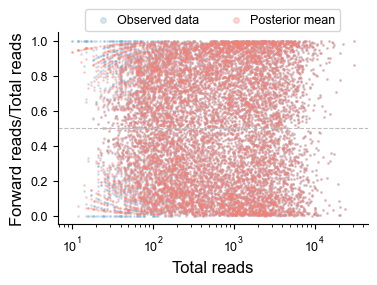

In [13]:
# Empirical Bayes shrinkage

for d in ds:	
	fig, ax = plt.subplots(figsize=(4, 2.5))

	ax.scatter(df_fwd_frac[d]["Total counts"], df_fwd_frac[d]["Observed forward fraction"], s=1, alpha=0.3, color="#80b1d3", label="Observed data")
	ax.scatter(df_fwd_frac[d]["Total counts"], df_fwd_frac[d]["Posterior mean"], s=1, alpha=0.3, color="#fb8072", label="Posterior mean")
	
	# Reference line (prior mean)
	ax.axhline(0.5, linestyle="--", color="#bdbdbd", linewidth=lw)
	
	ax.set_xscale("log")
	ax.set_xlabel("Total reads", fontsize=bfontsize)
	ax.set_ylabel("Forward reads/Total reads", fontsize=bfontsize)
	
	ax.spines[["top", "right"]].set_visible(False)
	ax.legend(loc="upper center", bbox_to_anchor=(0.5,1.15), fontsize=sfontsize, 
			 ncols=2, handletextpad=0.1, markerscale=4)
	ax.tick_params(labelsize=sfontsize)

	figN = "SuppFig7" if d == "distal" else "SuppFig8"
	plt.savefig(f"{PROJECT_DIR_o}figures/{figN}b.png", bbox_inches="tight", transparent=True, dpi=300)

## Strand imbalance

In [14]:
# Expression bins

bins = [0, 20, 40, 60, 80, 100, 150, 200, 500, np.inf]
labels = ["<20", "20–39", "40–59", "60–79", "80–99", "100–149", "150–199", "200-500", "500+"]

In [15]:
def posterior_probs(counts_fwd, total_counts, alpha):
	# Pr(p≤0.5): reverse-biased; note Pr(p=0.5)=0
    p_reverse = beta.cdf(0.5, counts_fwd + alpha, total_counts - counts_fwd + alpha)
	# Pr(p>0.5): forward-biased
    p_forward = 1 - p_reverse
    return p_forward, p_reverse

In [16]:
prior_types = {}
for d in ds:
	prior_types[d] = [f"Empirical Bayes ($\\alpha=\\beta=${round(alphas[d],2)})", "Jeffreys prior ($\\alpha=\\beta=$0.5)", "Uniform prior ($\\alpha=\\beta=$1)", "Bell-shaped ($\\alpha=\\beta=$2)"]

In [17]:
df_all = {}
for d in ds:
	dfs = []
	# Test different prior distributions
	for prior_type in prior_types[d]:
		if "Empirical Bayes" in prior_type:
			alpha = alphas[d]
		elif "Jeffrey" in prior_type:
			alpha = 0.5
		elif "Uniform" in prior_type:
			alpha = 1
		else:
			alpha = 2
		for p in ps:
			df = pd.read_table(f"{PROJECT_DIR_d}Analysis/C1_filtered_{p}_{d}_counts_DI.text", index_col=0)
			df["prior_type"] = prior_type
			df["bin"] = pd.cut(df["total_counts"], bins=bins, labels=labels, right=False)
			df["counts_fwd"] = df["counts_fwd"].astype(int)
			df["total_counts"] = df["total_counts"].astype(int)
			post_probs = df.apply(lambda row: posterior_probs(row["counts_fwd"], row["total_counts"], alpha), axis=1)
			df["post_prob_forward"] = [x[0] for x in post_probs]
			df["post_prob_reverse"] = [x[1] for x in post_probs]
			df["post_prob_max"] = np.maximum(df["post_prob_forward"], df["post_prob_reverse"])
			df["sig"] = df["post_prob_max"] > 0.99
			df["peak_type"] = p
			df["absDI"] = df["DI"].abs()
			dfs.append(df)
	df_all[d] = pd.concat(dfs)

In [18]:
# Source data for SuppFig. 7c & d and SuppFig. 8c & d

df_sig_frac = {}
for d in ds:
	results = []
	for p, label, prior_type in itertools.product(ps, labels, prior_types[d]):
		df = df_all[d][(df_all[d]["peak_type"]==p) & (df_all[d]["bin"]==label) & (df_all[d]["prior_type"]==prior_type)]
		n_total = len(df)
		n_sig = (df["sig"]).sum()
		perc = n_sig/n_total*100
		results.append([p.capitalize(), label, prior_type, n_sig, n_total, perc])
	df_sig_frac[d] = pd.DataFrame(results, columns=["peak_type", "bin", "prior_type", "n_sig", "n_total", "percent"])
	figN = "SuppFig7" if d == "distal" else "SuppFig8"
	df_sig_frac[d].to_csv(f"{PROJECT_DIR_o}source_data/{figN}cd/{d}_strand_imbalance.txt", sep="\t", index=False)

In [20]:
def plot_fraction(df_frac, outputfile):
	fig, ax = plt.subplots(figsize=(9,2.7))
	g = sns.barplot(data=df_frac, x="bin", y="percent", hue="peak_type", 
					palette = ["#313695", "#de77ae"], alpha=0.5, ax=ax)
	g.spines[["top", "right"]].set_visible(False)
	g.set_xlabel("Total count bin", fontsize=bfontsize)
	g.set_ylabel("%TREs with strand imbalance\n(posterior probability>0.99)", fontsize=bfontsize)
	g.legend(loc="upper center", bbox_to_anchor=(0.2,1.1), ncols=2, fontsize=sfontsize, frameon=False)
	g.tick_params(labelsize=sfontsize)
	g.set_title("Empirical Bayes", fontsize=bfontsize, y=1.05)

	for container in g.containers:
		for bar in container:
			height = bar.get_height()
			if np.isnan(height):
				continue
	
			idx = list(g.patches).index(bar)
			if idx >= len(df_frac):
				continue

			r = df_frac.iloc[idx]
			label = f"{r['n_sig']}/{r['n_total']}"

			height = 5 if r['n_sig']==0 else height * 0.2
			g.text(
				bar.get_x() + bar.get_width() / 2,
				height,
				label,
				ha='center',
				va='bottom',
				fontsize=sfontsize,
				rotation=90,
				color="#000000"
			)
	plt.savefig(outputfile, bbox_inches="tight", transparent=True)

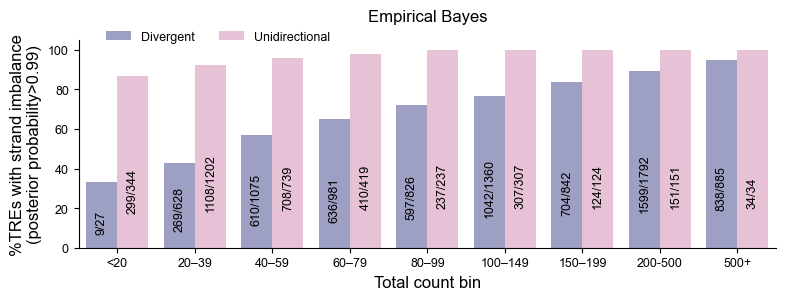

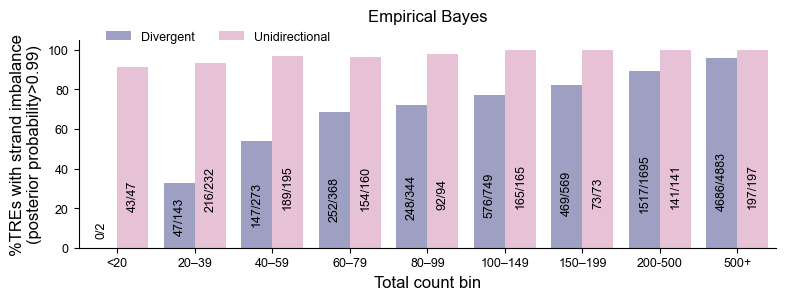

In [21]:
for d in ds:
	figN = "SuppFig7" if d == "distal" else "SuppFig8"
	df = df_sig_frac[d][df_sig_frac[d]["prior_type"].str.contains("Empirical Bayes")]
	plot_fraction(df, f"{PROJECT_DIR_o}figures/{figN}c.pdf")

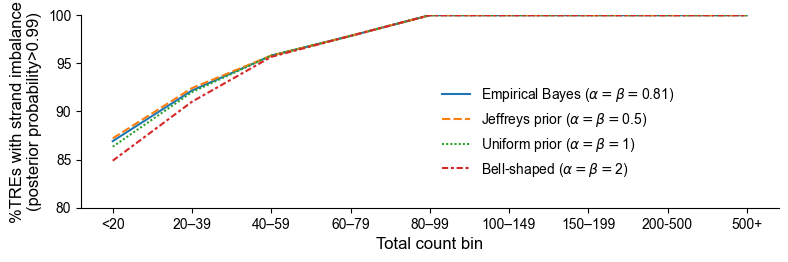

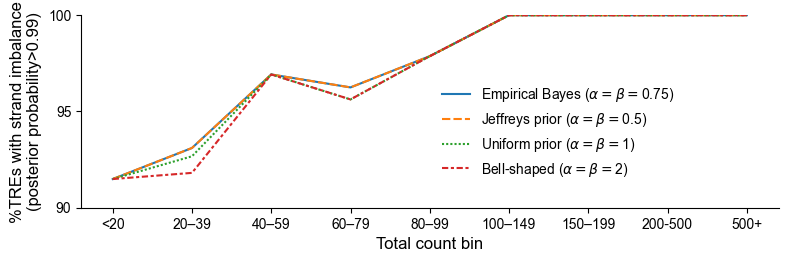

In [22]:
for d in ds:
	fig, ax = plt.subplots(figsize=(9,2.5))
	g = sns.lineplot(data=df_sig_frac[d][df_sig_frac[d]["peak_type"]=="Unidirectional"], x="bin", y="percent", 
					 hue="prior_type",  style="prior_type", errorbar=None, ax=ax)
	g.spines[["top", "right"]].set_visible(False)
	if d == "distal":
		g.set_ylim([80,100])
		g.set_yticks([80,85,90,95,100])
	else:
		g.set_ylim([90,100])
		g.set_yticks([90,95,100])
	g.set_xlabel("Total count bin", fontsize=bfontsize)
	g.set_ylabel("%TREs with strand imbalance\n(posterior probability>0.99)", fontsize=bfontsize)
	g.legend(loc="upper left", bbox_to_anchor=(0.5, 0.7), frameon=False)
	figN = "SuppFig7" if d == "distal" else "SuppFig8"
	plt.savefig(f"{PROJECT_DIR_o}figures/{figN}d.pdf", bbox_inches="tight", transparent=True)

# DI vs. counts in divergent elements

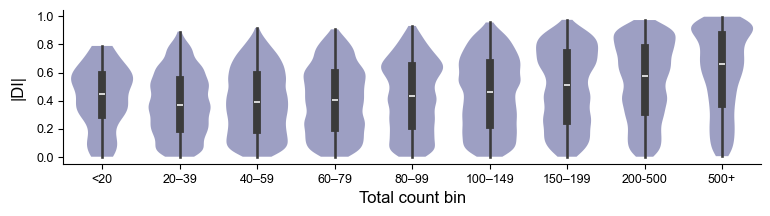

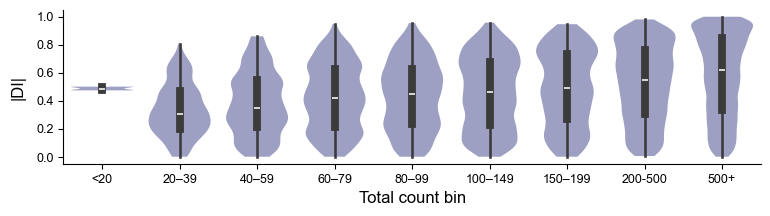

In [24]:
# Source data for SuppFig. 7e and SuppFig. 8e

for d in ds:
	fig, ax = plt.subplots(figsize=(9,2))
	df = df_all[d][df_all[d]["peak_type"]=="divergent"][["bin", "absDI"]]
	figN = "SuppFig7" if d == "distal" else "SuppFig8"
	df.to_csv(f"{PROJECT_DIR_o}source_data/{figN}e/{d}_abs_DI.txt", sep="\t")
	
	g = sns.violinplot(data=df, x="bin", y="absDI", cut=0, density_norm="width", color="#313695", alpha=0.5, ax=ax)
	for collection in g.collections:
		collection.set_edgecolor("none")
	g.spines[["top", "right"]].set_visible(False)
	g.tick_params(labelsize=sfontsize)
	g.set_xlabel("Total count bin", fontsize=bfontsize)
	g.set_ylabel("|DI|", fontsize=bfontsize, labelpad=8)
	figN = "SuppFig7" if d == "distal" else "SuppFig8"
	plt.savefig(f"{PROJECT_DIR_o}figures/{figN}e.pdf", bbox_inches="tight", transparent=True)